In [33]:
# packages
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import (load_data, confusion_table)
from ISLP.models import (ModelSpec as MS, summarize, contrast)
from sklearn.model_selection import train_test_split 
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, roc_auc_score

roc_curve_est = RocCurveDisplay.from_estimator 
roc_curve_pred = RocCurveDisplay.from_predictions 


# set seed
seed = 5331

### We will use the OJ dataset, which contains information about orange juice purchases across different stores.

In [34]:
OJ = load_data('OJ')
OJ

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.00,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.30,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.00,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.00,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.00,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1065,CH,252,7,1.86,2.09,0.10,0.00,0,0,0.587822,2.09,1.76,0.33,Yes,0.000000,0.053763,0.23,0
1066,CH,256,7,1.86,2.18,0.00,0.00,0,0,0.670258,2.18,1.86,0.32,Yes,0.000000,0.000000,0.32,0
1067,MM,257,7,1.86,2.18,0.00,0.00,0,0,0.736206,2.18,1.86,0.32,Yes,0.000000,0.000000,0.32,0
1068,CH,261,7,1.86,2.13,0.00,0.24,0,0,0.588965,1.89,1.86,0.03,Yes,0.112676,0.000000,0.27,0


### What are the variables and their types?

In [35]:
OJ.dtypes

Purchase          category
WeekofPurchase       int64
StoreID              int64
PriceCH            float64
PriceMM            float64
DiscCH             float64
DiscMM             float64
SpecialCH            int64
SpecialMM            int64
LoyalCH            float64
SalePriceMM        float64
SalePriceCH        float64
PriceDiff          float64
Store7            category
PctDiscMM          float64
PctDiscCH          float64
ListPriceDiff      float64
STORE                int64
dtype: object

### We will use all stores other than ID=7 as training data, and Store #7 will be used as test.

In [36]:
OJ["StoreID"].value_counts()

StoreID
7    356
2    222
3    196
1    157
4    139
Name: count, dtype: int64

In [37]:
Train = OJ[OJ['StoreID'] != 7]
Train

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
16,MM,240,1,1.75,1.99,0.00,0.3,0,1,0.500000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1059,CH,235,1,1.69,1.99,0.00,0.0,0,0,0.619072,1.99,1.69,0.30,No,0.000000,0.000000,0.30,1
1060,MM,236,1,1.75,1.99,0.00,0.0,0,0,0.695258,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1061,MM,242,1,1.86,1.99,0.00,0.3,0,1,0.556206,1.69,1.86,-0.17,No,0.150754,0.000000,0.13,1
1063,CH,251,1,1.76,2.09,0.00,0.0,0,0,0.355972,2.09,1.76,0.33,No,0.000000,0.000000,0.33,1


In [38]:
Test = OJ[OJ['StoreID']==7]

### We will predict whether each customer purchased Citrus Hill or Minute Maid.

In [39]:
y_train = Train.Purchase == 'CH'
y_test = Test.Purchase == 'CH'

In [40]:
X_train = Train[['WeekofPurchase', 'PriceCH', 'PriceMM', 'DiscCH', 'DiscMM', 'SpecialCH', 'SpecialMM', 'LoyalCH', 'SalePriceCH', 'SalePriceMM', 'PriceDiff', 'PctDiscCH', 'PctDiscMM', 'ListPriceDiff']]
X_test = Test[['WeekofPurchase', 'PriceCH', 'PriceMM', 'DiscCH', 'DiscMM', 'SpecialCH', 'SpecialMM', 'LoyalCH', 'SalePriceCH', 'SalePriceMM', 'PriceDiff', 'PctDiscCH', 'PctDiscMM', 'ListPriceDiff']]

In [41]:
X_train.corr()

,WeekofPurchase,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceCH,SalePriceMM,PriceDiff,PctDiscCH,PctDiscMM,ListPriceDiff
WeekofPurchase,1.000000,0.699424,0.538580,0.251239,0.380114,-0.064880,0.142871,0.145285,0.570896,-0.013168,-0.256620,0.221724,0.370996,0.022029
PriceCH,0.699424,1.000000,0.608199,0.276778,0.202634,-0.068728,-0.035175,0.108543,0.860010,0.178482,-0.188608,0.241624,0.193308,-0.169434
PriceMM,0.538580,0.608199,1.000000,-0.086294,0.062640,-0.144215,0.009530,0.092089,0.658272,0.524282,0.242621,-0.103473,0.047592,0.679258
DiscCH,0.251239,0.276778,-0.086294,1.000000,0.007251,0.243658,-0.144534,0.032394,-0.252311,-0.056042,0.051662,0.996274,0.012602,-0.363038
DiscMM,0.380114,0.202634,0.062640,0.007251,1.000000,0.031781,0.624014,0.006436,0.200199,-0.817031,-0.900975,0.001807,0.998936,-0.109575
SpecialCH,-0.064880,-0.068728,-0.144215,0.243658,0.031781,1.000000,-0.104348,0.014230,-0.198596,-0.110433,-0.025542,0.267632,0.035488,-0.115511
SpecialMM,0.142871,-0.035175,0.009530,-0.144534,0.624014,-0.104348,1.000000,-0.061369,0.041330,-0.526915,-0.543615,-0.136750,0.625448,0.044354
LoyalCH,0.145285,0.108543,0.092089,0.032394,0.006436,0.014230,-0.061369,1.000000,0.092099,0.047711,0.008349,0.024488,0.005399,0.013981
SalePriceCH,0.570896,0.860010,0.658272,-0.252311,0.200199,-0.198596,0.041330,0.092099,1.000000,0.209489,-0.217359,-0.285733,0.187967,0.022164
SalePriceMM,-0.013168,0.178482,0.524282,-0.056042,-0.817031,-0.110433,-0.526915,0.047711,0.209489,1.000000,0.908899,-0.061321,-0.824816,0.485918


/var/folders/qf/2nxp2yzd1gbb5qllnxj86tw80000gn/T/ipykernel_6971/2057505033.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/qf/2nxp2yzd1gbb5qllnxj86tw80000gn/T/ipykernel_6971/2057505033.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/qf/2nxp2yzd1gbb5qllnxj86tw80000gn/T/ipykernel_6971/2057505033.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/qf/2nxp2yzd1gbb5qllnxj86tw80000gn/T/ipykernel_6971/2057505033.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; supp

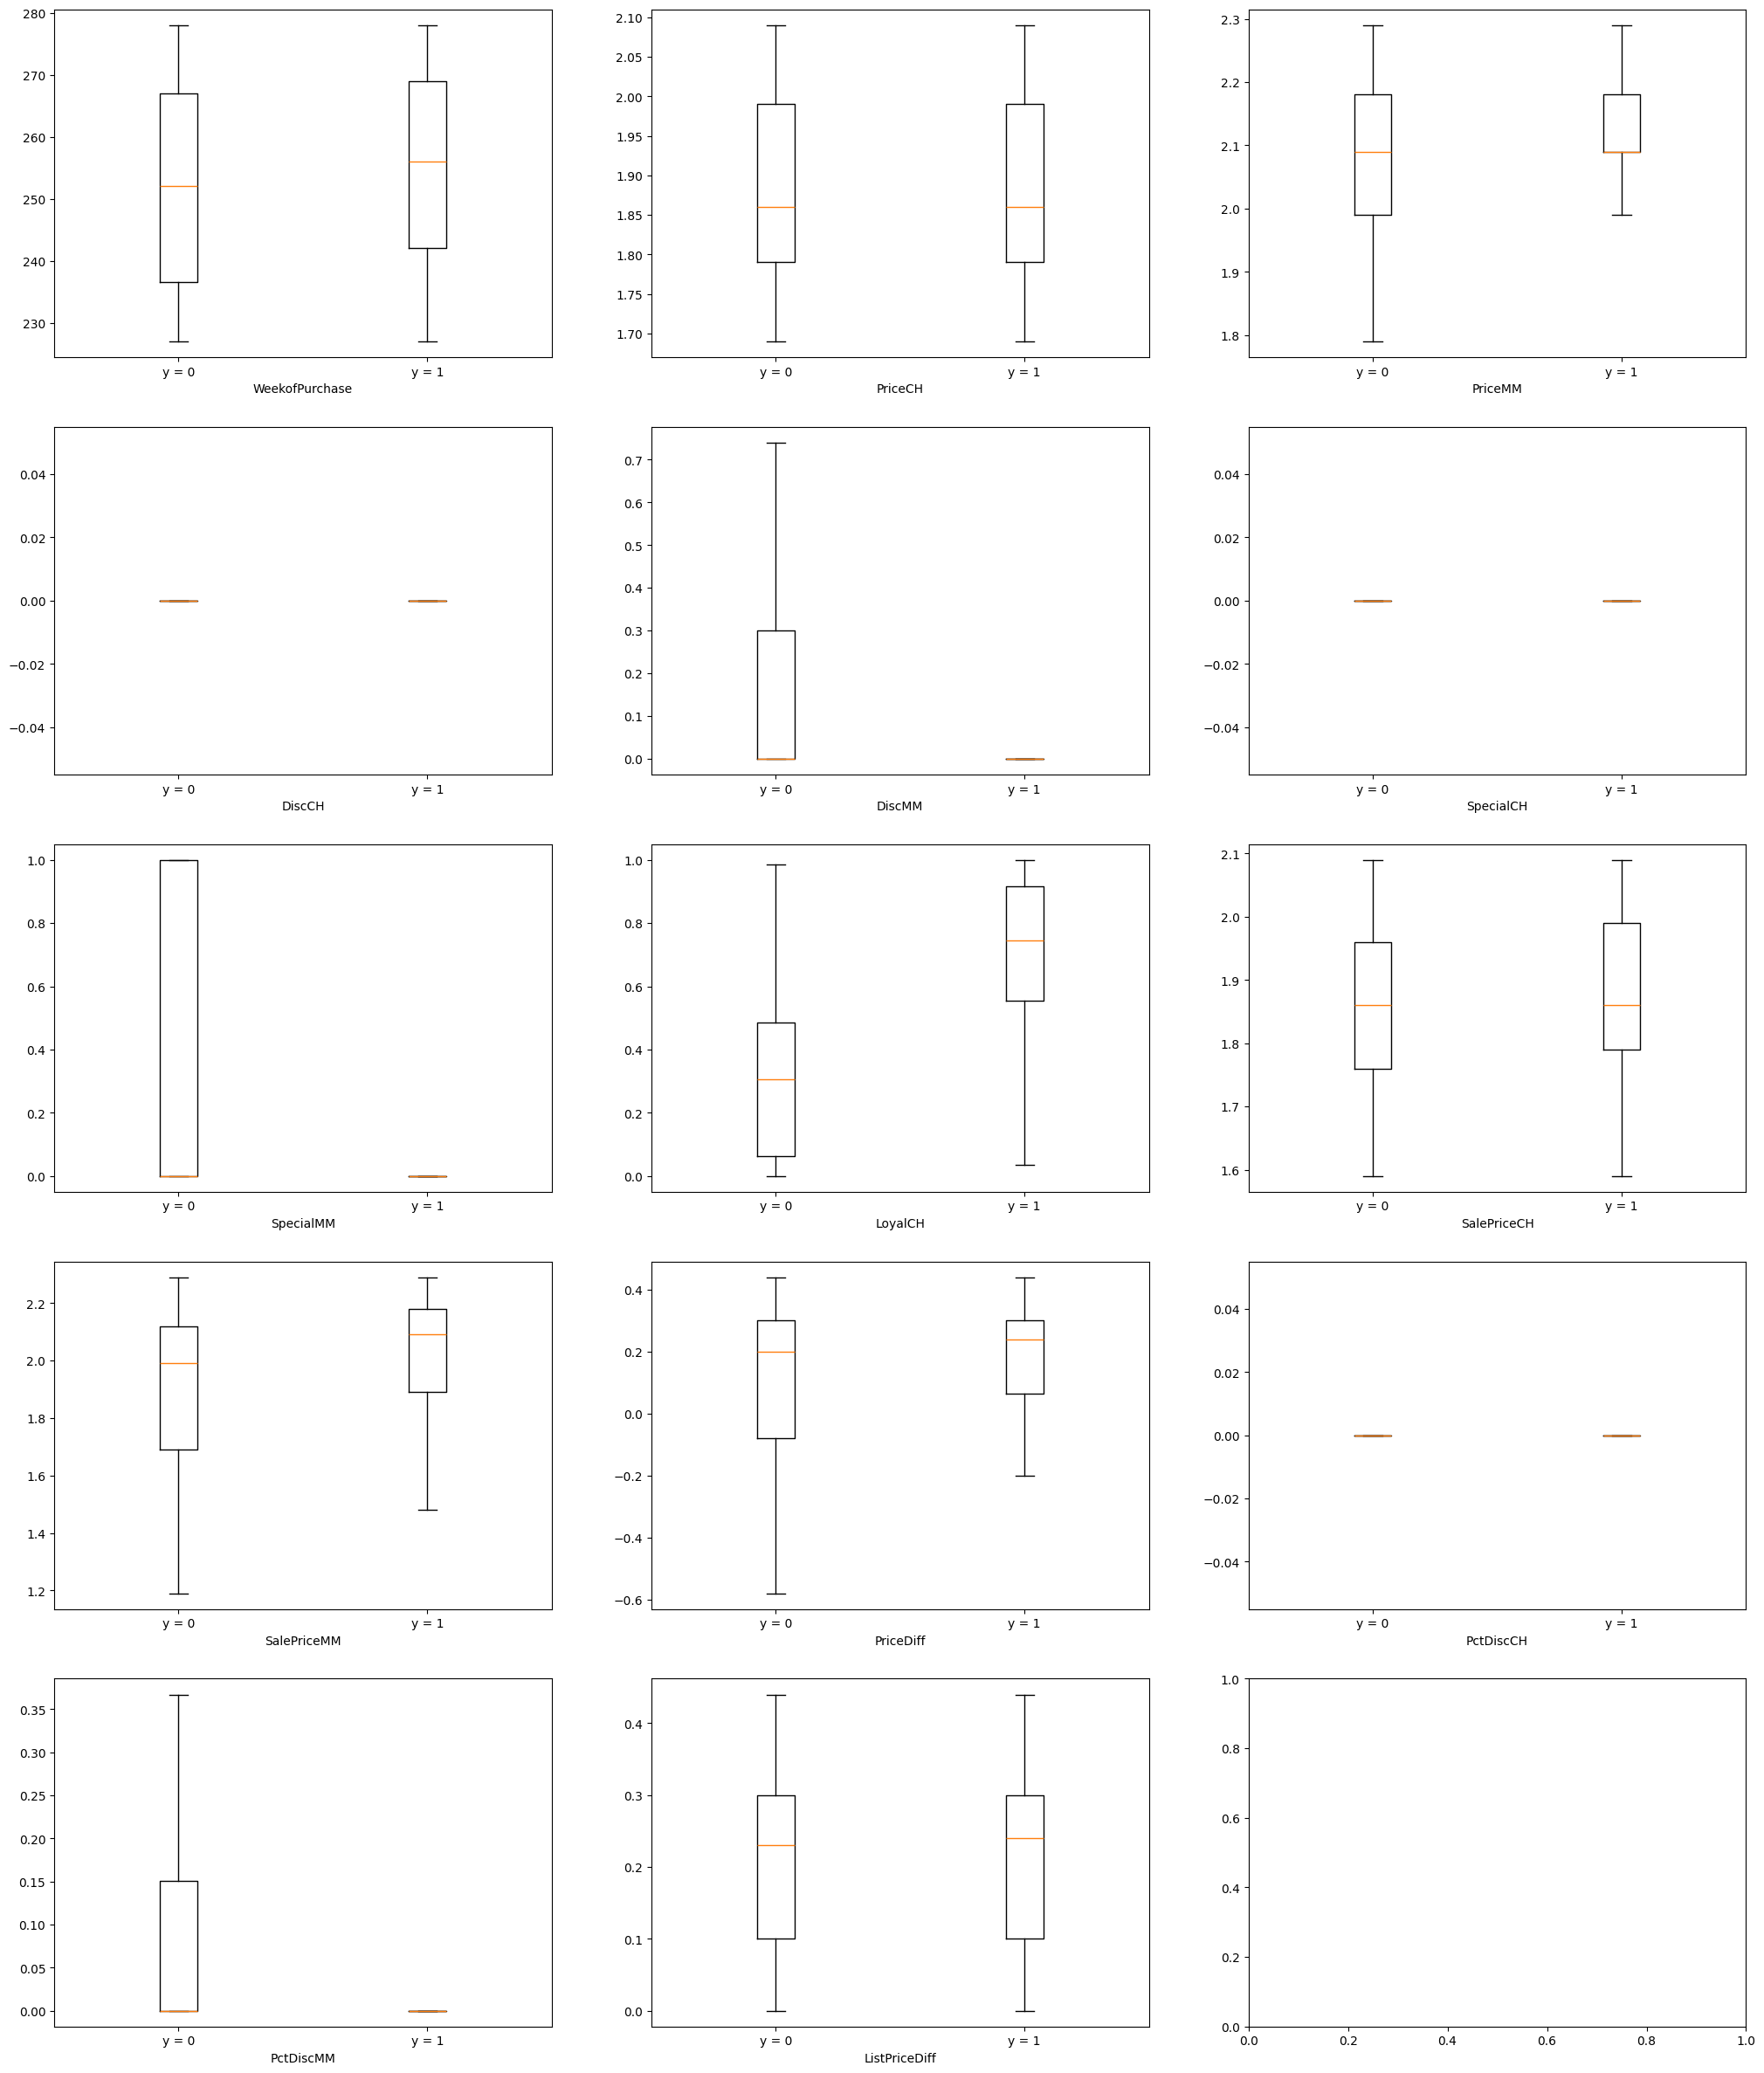

In [42]:
# Initialize the plots before drawing them
nrows = 5
ncols = 3
figsize = (5*nrows, 10*ncols)

fig, axes = subplots(nrows=nrows,
                     ncols=ncols,
                     figsize=figsize)

# Assign a grid location to each index
def range_to_grid(i, nrows, ncols):
    x=[]
    y=[]
    for n in range(nrows*ncols):
        x.append(n // ncols)
        y.append(n % ncols)
        # print(n,x[n],y[n]) # for testing this function
    return x[i],y[i]

# Plot the variables as paired boxplots
for j, col in enumerate(X_train.columns):
    r, c = range_to_grid(j, nrows, ncols)
    ax = axes[r, c]

    data_0 = X_train.loc[y_train == 0, col]
    data_1 = X_train.loc[y_train == 1, col]

    ax.boxplot(
        [data_0, data_1],
        labels=["y = 0", "y = 1"],
        showfliers=False
    )

    ax.set_xlabel(col)


In [43]:
X_train['intercept'] = np.ones(X_train.shape[0])
X_test['intercept'] = np.ones(X_test.shape[0])

/var/folders/qf/2nxp2yzd1gbb5qllnxj86tw80000gn/T/ipykernel_6971/286339022.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['intercept'] = np.ones(X_train.shape[0])
/var/folders/qf/2nxp2yzd1gbb5qllnxj86tw80000gn/T/ipykernel_6971/286339022.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['intercept'] = np.ones(X_test.shape[0])


## Logistic Regression

### Since the many of the variables are correlated, a model with all of them will likely be overfit.

In [44]:
# build model
initial_glm = sm.GLM(y_train,
             X_train,
             family=sm.families.Binomial())

# fit model
initial_results = initial_glm.fit()

# analyze model
summarize(initial_results)

,coef,std err,z,P>|z|
WeekofPurchase,0.0088,0.011,0.825,0.410
PriceCH,-6.3630,6.033,-1.055,0.292
PriceMM,-3.9333,3.166,-1.242,0.214
DiscCH,-12.6320,12.252,-1.031,0.303
DiscMM,-9.3949,6.426,-1.462,0.144
SpecialCH,-0.3938,0.508,-0.776,0.438
SpecialMM,-0.6652,0.350,-1.902,0.057
LoyalCH,6.3115,0.458,13.783,0.000
SalePriceCH,6.2690,6.254,1.002,0.316
SalePriceMM,5.4616,3.292,1.659,0.097


### Create a logistic model using only the intercept, Citrus Hill loyalty, and the difference in price between the brands.

In [45]:
var_list = ['intercept', 'LoyalCH', 'PriceDiff']

# build model
glm = glm = sm.GLM(y_train, X_train[var_list], family=sm.families.Binomial())

# fit model
results = glm.fit()

# analyze model
summarize(results)

,coef,std err,z,P>|z|
intercept,-3.4159,0.266,-12.820,0.0
LoyalCH,6.3811,0.456,14.008,0.0
PriceDiff,2.5729,0.426,6.043,0.0


### Get the predicted probabilities

In [46]:
def predict(X, model):
    # the built-in get_prediction tool returns an array, so we need to convert to a dataframe
    predictions_df = pd.DataFrame(model.get_prediction(X).predicted, columns=['y_hat'], index=X.index)
    return predictions_df['y_hat']

In [47]:
probs_train=predict(X_train[var_list],results)
probs_test=predict(X_test[var_list],results)

### We'll use 0.5 as the threshold for True vs. False

In [48]:
predictions_train = np.array([True]*len(y_train))
predictions_train[probs_train<0.5] = False

predictions_test = np.array([True]*len(y_test))
predictions_test[probs_test<0.5] = False

### Training results

In [49]:
train_table = confusion_table(predictions_train, y_train)
train_table

Truth,False,True
Predicted,,
False,270,61
True,65,318


### Test results

In [50]:
test_table = confusion_table(predictions_test, y_test)
test_table

Truth,False,True
Predicted,,
False,60,34
True,22,240


### Calculate the false positive rate and false negative rate for this model.

You can hard code the exact numbers to at least **three** decimal places, or you can code a formula that correcly calculates this. 

In [51]:
false_positive_rate = 0.268
print("fpr =", false_positive_rate)

false_negative_rate = 0.124
print("fnr =", false_negative_rate)

fpr = 0.268
fnr = 0.124


## Naive Bayes and k-Nearest Neighbors

### Create arrays of train and test sets

In [52]:
var_list.remove('intercept')

X_train_array, X_test_array = [np.asarray(X) for X in [X_train[var_list], X_test[var_list]]]

### Build Naive Bayes classifer

In [53]:
naive = GaussianNB()
naive.fit(X_train_array, y_train)
naive_test = naive.predict(X_test_array)
naive_probs = naive.predict_proba(X_test_array)[:,1]

confusion_table(naive_test, y_test)

Truth,False,True
Predicted,,
False,64,39
True,18,235


### Try different k-Nearest Neigbors classifiers

In [54]:
# Let's try 5 nearest neighbors

knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train_array, y_train)
knn5_test = knn5.predict(X_test_array)

confusion_table(knn5_test, y_test)

Truth,False,True
Predicted,,
False,60,49
True,22,225


In [55]:
# How about 50 nearest neighbors?

knn50 = KNeighborsClassifier(n_neighbors=50)
knn50.fit(X_train_array, y_train)
knn50_test = knn50.predict(X_test_array)

confusion_table(knn50_test, y_test)

Truth,False,True
Predicted,,
False,63,42
True,19,232


In [56]:
# How about 500 nearest neighbors?

knn500 = KNeighborsClassifier(n_neighbors=500)
knn500.fit(X_train_array, y_train)
knn500_test = knn500.predict(X_test_array)

confusion_table(knn500_test, y_test)

Truth,False,True
Predicted,,
False,49,24
True,33,250


### Write a loop to test all kNN models from k=1 to 500. 

### Return the lowest value of k which maximizes the number of correct predictions on the test set. You can obtain these numbers from the main diagonal of the confusion matrix.

In [ ]:
best_k = 0
num_correct_pred = 0

for k in range(1,501):

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_array, y_train)
    knn_test = knn.predict(X_test_array)

    table = confusion_table(knn_test, y_test)
    num_correct = table.iloc[0,0] + table.iloc[1,1]

    if num_correct > num_correct_pred:
        num_correct_pred = num_correct
        best_k = k

print(best_k)
print(num_correct_pred)

### Now that you've found an optimal choice of k, let's construct that model and store it.

In [ ]:
knn_opt = KNeighborsClassifier(n_neighbors=best_k
                               )
knn_opt.fit(X_train_array, y_train)
knn_opt_test = knn_opt.predict(X_test_array)

confusion_table(knn_opt_test, y_test)

Truth,False,True
Predicted,,
False,60,30
True,22,244


### ROC Curves

/Users/charlottemanalo/code_2600/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/charlottemanalo/code_2600/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/charlottemanalo/code_2600/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/charlottemanalo/code_2600/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dicti

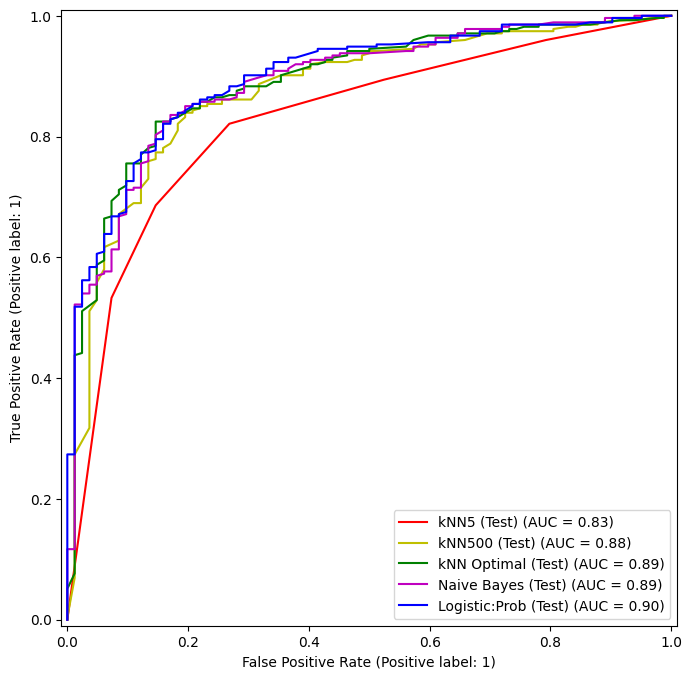

In [ ]:
fig, ax = subplots(figsize=(8,8))

roc_curve_est(knn5,
              X_test_array,
              y_test,
              name='kNN5 (Test)',
              color='r',
              ax=ax);

roc_curve_est(knn500,
              X_test_array,
              y_test,
              name='kNN500 (Test)',
              color='y',
              ax=ax);

roc_curve_est(knn_opt,
              X_test_array,
              y_test,
              name='kNN Optimal (Test)',
              color='g',
              ax=ax);

roc_curve_est(naive,
              X_test_array,
              y_test,
              name='Naive Bayes (Test)',
              color='m',
              ax=ax);

roc_curve_pred(y_test,
               probs_test,
               name='Logistic:Prob (Test)',
               color='b',
               ax=ax);
#fig

# Discussion Questions

### Of the models that were built in this notebook, which would you choose to implement? Why?

I would choose the logistic regression model. Based on the ROC curves, logistic regression has the highest AUC value, which indicates that it performs the best at distinguishing between customers who purchase Citrus Hill and those who purchase Minute Maid. Logistic regression is also simpler and more interpretable than k-nearest neighbors, making it easier to understand how the predictors affect the probability of purchase

### Suppose we "build" a model on this data that **always predicts true**, i.e., that every customer will purchase Citrus Hill rather than Minute Maid orange juice. What would be the total misclassification rate on this test set?

You can hard code the exact number to at least **three** decimal places, or you can code a formula that correcly calculates this. 

In [ ]:
misclassification_rate = 0.230
print(misclassification_rate)

0.23
